# [4장 1강] 실습: 군집화

## 실습 목표

- 정답 Label이 없는 고객 데이터를 비지도학습 문제로 정의할 수 있다.
- K-Means가 중심점과 거리 기준으로 고객을 군집화하는 원리를 설명할 수 있다.
- 품목별 구매금액을 표준화할 수 있다.
- Elbow Method로 적절한 군집 개수 K를 검토할 수 있다.
- 고객별 군집과 군집 중심을 생성하고 특성을 해석할 수 있다.
- 군집 결과를 고객 세분화와 영업·마케팅 전략에 연결할 수 있다.

## 사용 데이터

- 파일: `Wholesale customers data.csv`
- 데이터 크기: 440행 × 8열
- 군집화 변수: `Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`
- 보조 해석 변수: `Channel`, `Region`

## 진행 방식

- 각 문제의 설명과 요구사항을 확인한 뒤 코드 셀을 작성합니다.
- 군집 번호 자체에 순서나 우수·열등의 의미를 부여하지 않습니다.

## 실습 준비: 데이터 불러오기

Google Colab에서는 파일을 Google Drive의 `MyDrive`에 저장합니다. Jupyter Notebook에서는 노트북과 같은 폴더에 저장합니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount('/content/drive')
    file_path='/content/drive/MyDrive/Wholesale customers data.csv'
except ModuleNotFoundError:
    file_path='Wholesale customers data.csv'

wholesale_df=pd.read_csv(file_path)
display(wholesale_df.head())
print('데이터 크기:',wholesale_df.shape)
wholesale_df.info()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


데이터 크기: (440, 8)
<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


## 필수 1: 고객 세분화 문제 정의와 데이터 준비

### 문제 1-1: 군집화 변수 선택과 표준화 수행하기

#### 문제 설명

도매업체는 구매 패턴이 비슷한 고객을 묶어 그룹별 영업 전략을 세우려고 합니다. 고객 그룹에 대한 정답 Label은 없으므로 6개 품목의 연간 구매금액을 기준으로 자연스럽게 형성되는 군집을 찾습니다.

#### 요구사항

1. 결측치와 중복 행 개수를 확인합니다.
2. `Channel`, `Region`을 군집화 변수에서 제외하고 이유를 설명합니다.
3. 6개 구매금액 컬럼을 선택하여 `purchase_df`를 만듭니다.
4. 구매금액의 기초 통계량을 출력합니다.
5. `Milk`와 `Grocery`의 산점도를 작성합니다.
6. StandardScaler로 6개 구매금액을 표준화합니다.
7. 표준화 전후 평균과 모집단 표준편차를 확인합니다.
8. 지도학습처럼 Train/Test 분할이 필수적이지 않은 이유를 설명합니다.

#### 출력 결과

- 결측치 0개, 중복 행 0개
- 군집화 데이터 크기 `(440, 6)`
- 품목별 기초 통계량
- 표준화 후 평균 0, 표준편차 1에 가까운 결과

#### 결과 해석 작성

> `Channel`, `Region`을 군집 생성에서 제외한 이유와 군집화에서 Train/Test 분할이 필수적이지 않은 이유는 무엇인가요?

중복 행 0
결측치 Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

군집화 데이터 크기: (440, 6)

=== 구매금액 기초 통계량 ===


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


c:\data-process-visualization\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 50752 (\N{HANGUL SYLLABLE WA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\data-process-visualization\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\data-process-visualization\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\data-process-visualization\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\data-process-visualization\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 50529 (\N{HANGUL SYLLABLE AEG}) missing from

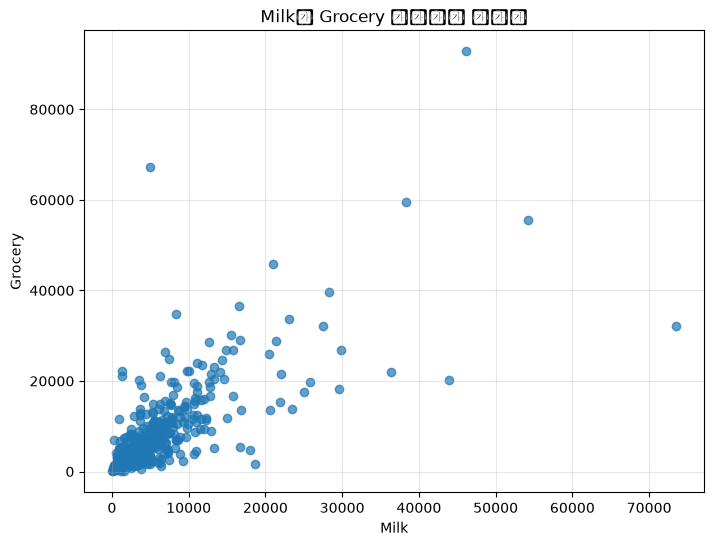


=== 표준화 전 ===
평균:


Fresh               12000.297727
Milk                 5796.265909
Grocery              7951.277273
Frozen               3071.931818
Detergents_Paper     2881.493182
Delicassen           1524.870455
dtype: float64

모집단 표준편차:


Fresh               12632.948725
Milk                 7371.985612
Grocery              9492.357638
Frozen               4849.153520
Detergents_Paper     4762.433350
Delicassen           2816.899449
dtype: float64


=== 표준화 후 ===
평균:


Fresh              -3.431598e-17
Milk                0.000000e+00
Grocery            -4.037175e-17
Frozen              3.633457e-17
Detergents_Paper    2.422305e-17
Delicassen         -8.074349e-18
dtype: float64

모집단 표준편차:


Fresh               1.0
Milk                1.0
Grocery             1.0
Frozen              1.0
Detergents_Paper    1.0
Delicassen          1.0
dtype: float64

In [4]:
print("중복 행",wholesale_df.duplicated().sum())
print("결측치", wholesale_df.isnull().sum())

purchase_cols = [
    'Fresh',
    'Milk',
    'Grocery',
    'Frozen',
    'Detergents_Paper',
    'Delicassen'
]
purchase_df = wholesale_df[purchase_cols].copy()

print('\n군집화 데이터 크기:', purchase_df.shape)

print('\n=== 구매금액 기초 통계량 ===')
display(purchase_df.describe())

plt.figure(figsize=(8, 6))

plt.scatter(
    purchase_df['Milk'],
    purchase_df['Grocery'],
    alpha=0.7
)

plt.xlabel('Milk')
plt.ylabel('Grocery')
plt.title('Milk와 Grocery 구매금액 산점도')
plt.grid(alpha=0.3)

plt.show()

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

purchase_scaled = scaler.fit_transform(purchase_df)

purchase_scaled_df = pd.DataFrame(
    purchase_scaled,
    columns=purchase_df.columns,
    index=purchase_df.index
)

print('\n=== 표준화 전 ===')

print('평균:')
display(purchase_df.mean())

print('모집단 표준편차:')
display(purchase_df.std(ddof=0))


print('\n=== 표준화 후 ===')

print('평균:')
display(purchase_scaled_df.mean())

print('모집단 표준편차:')
display(purchase_scaled_df.std(ddof=0))

## 필수 2: Elbow Method로 적절한 K 선택

### 문제 2-1: K별 Inertia 계산과 Elbow 그래프 작성하기

#### 문제 설명

K를 1부터 10까지 변경하면서 각 데이터와 소속 군집 중심 사이의 거리 제곱합인 Inertia가 어떻게 감소하는지 확인합니다. Elbow 형태와 실제 운영 가능한 그룹 수를 함께 고려해 K를 선택합니다.

#### 요구사항

1. K를 1부터 10까지 변경합니다.
2. 각 K에서 `random_state=42`, `n_init=10`으로 K-Means를 학습합니다.
3. 각 모델의 `inertia_`를 저장합니다.
4. K별 Inertia 표와 선 그래프를 만듭니다.
5. 감소 폭이 완만해지는 구간과 군집 운영 가능성을 함께 고려해 K=2를 선택합니다.
6. Elbow Method만으로 K가 항상 명확하게 결정되지 않는 이유를 설명합니다.

#### 결과 해석 작성

> 이 데이터에서 K=2를 선택한 근거는 무엇이며, Elbow Method만으로 하나의 정답 K를 확정할 수 없는 이유는 무엇인가요?

,K,Inertia
0,1,2640.000000
1,2,1956.124278
2,3,1608.431149
3,4,1317.838361
4,5,1058.771253
5,6,915.741260
6,7,825.400252
7,8,737.386203
8,9,661.449585
9,10,605.915109


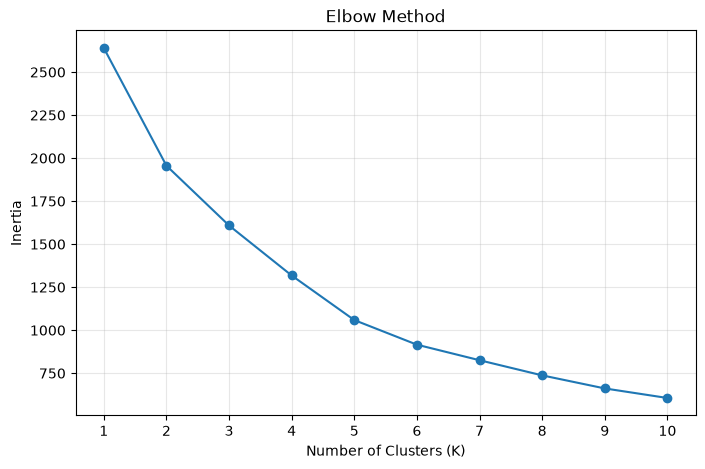

In [9]:
from sklearn.cluster import KMeans

inertia_list = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(purchase_scaled_df)
    
    inertia_list.append(kmeans.inertia_)

# K별 Inertia 표
inertia_df = pd.DataFrame({
    'K': range(1, 11),
    'Inertia': inertia_list
})

display(inertia_df)

plt.figure(figsize=(8, 5))

plt.plot(
    inertia_df['K'],
    inertia_df['Inertia'],
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(range(1, 11))
plt.grid(alpha=0.3)

plt.show()

## 필수 3: K-Means 모델 학습과 고객 군집 해석

### 문제 3-1: 고객 군집 생성, 시각화 및 특성 분석하기

#### 문제 설명

K=2로 고객을 군집화하고 중심점과 품목별 구매 패턴을 분석합니다. `Channel`과 `Region`은 군집 생성에는 사용하지 않았지만, 생성된 군집에 어떤 고객 유형이 많이 포함됐는지 사후 해석하는 데 활용합니다.

#### 요구사항

1. `KMeans(n_clusters=2, random_state=42, n_init=10)`을 학습합니다.
2. 고객별 군집 번호를 만들고 원본을 복사한 `clustered_df`에 추가합니다.
3. 군집별 고객 수를 출력합니다.
4. 표준화 공간의 중심을 확인합니다.
5. `inverse_transform()`으로 중심을 원래 구매금액 단위로 복원합니다.
6. `Milk`–`Grocery` 산점도에 군집과 중심점을 표시합니다.
7. 군집별 6개 품목 평균을 표와 막대그래프로 비교합니다.
8. 군집별 `Channel`, `Region` 고객 수와 비율을 확인합니다.
9. 각 군집의 구매 특성과 영업·마케팅 전략을 작성합니다.
10. 군집 번호 자체에는 의미가 없음을 설명합니다.

#### 결과 해석 작성

> 두 군집은 구매 패턴과 Channel 구성에서 어떤 차이를 보이며, 각 군집에 어떤 영업 전략을 적용할 수 있나요?

## 실습 마무리

1. K-Means는 어떤 순서로 군집을 학습하나요?
2. StandardScaler를 적용하지 않으면 어떤 문제가 발생할 수 있나요?
3. 군집 번호를 곧바로 우수 고객 등급으로 해석하면 안 되는 이유는 무엇인가요?